# MIND News Recommendation System

This notebook trains and evaluates an explainable content-based news recommender using the Microsoft News Dataset (MINDlarge).

The system represents news titles with **TF-IDF**, builds a user profile from clicked articles, ranks unseen articles with sparse cosine similarity, and compares the personalized model with a popularity baseline.

> **Notebook outcome:** a reproducible `data/artifacts/model.pkl` artifact that can be loaded by the FastAPI inference service.

## Questions answered

- Which news articles are available to the model?
- How are titles converted into numerical features?
- How does a click history become a user-interest profile?
- Does personalized ranking outperform a popularity baseline?
- Can the saved artifact be reloaded and used for inference?

## Experiment design

The training split fits the text representation. The development split measures ranking quality. The test split remains untouched for a final experiment after model decisions are frozen.

The model is deliberately simple and explainable. It is a strong baseline for a production recommender because it is fast, sparse, deterministic, and easy to inspect.

In [23]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer


RANDOM_STATE = 42
TUNING_SAMPLE_SIZE = 5_000
TOP_K = 10

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
TRAIN_DIR = RAW_DATA_DIR / "MINDlarge_train"
DEV_DIR = RAW_DATA_DIR / "MINDlarge_dev"
TEST_DIR = RAW_DATA_DIR / "MINDlarge_test"
ARTIFACT_DIR = DATA_DIR / "artifacts"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODEL_PATH = ARTIFACT_DIR / "model.pkl"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

NEWS_COLUMNS = [
    "news_id", "category", "subcategory", "title",
    "abstract", "url", "title_entities", "abstract_entities",
]
BEHAVIOR_COLUMNS = [
    "impression_id", "user_id", "time", "history", "impressions",
]


def clean_text(value: object) -> str:
    text = "" if value is None else str(value).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


required_files = {
    "train_news": TRAIN_DIR / "news.tsv",
    "train_behaviors": TRAIN_DIR / "behaviors.tsv",
    "dev_news": DEV_DIR / "news.tsv",
    "dev_behaviors": DEV_DIR / "behaviors.tsv",
}
missing = {name: path for name, path in required_files.items() if not path.is_file()}
if missing:
    details = "\n".join(f"- {name}: {path}" for name, path in missing.items())
    raise FileNotFoundError(f"Required MIND files are missing:\n{details}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Model path:   {MODEL_PATH}")

Project root: /home/student/Downloads/mindNews-recommender/mind-news-recommender
Model path:   /home/student/Downloads/mindNews-recommender/mind-news-recommender/data/artifacts/model.pkl


## 1. Load and validate the data

MIND stores news metadata and impression events as tab-separated files without headers. The validation checks ensure the notebook fails early when the dataset layout is incorrect.

In [24]:
def load_news(directory: Path) -> pd.DataFrame:
    frame = pd.read_csv(
        directory / "news.tsv",
        sep="\t",
        names=NEWS_COLUMNS,
        header=None,
        keep_default_na=False,
    )
    frame = frame.drop_duplicates("news_id").copy()
    frame["title"] = frame["title"].fillna("").astype(str)
    frame["title_clean"] = frame["title"].map(clean_text)
    frame = frame[frame["title_clean"].ne("")].reset_index(drop=True)
    return frame


def load_behaviors(directory: Path) -> pd.DataFrame:
    return pd.read_csv(
        directory / "behaviors.tsv",
        sep="\t",
        names=BEHAVIOR_COLUMNS,
        header=None,
        keep_default_na=False,
    )


news = load_news(TRAIN_DIR)
train_behaviors = load_behaviors(TRAIN_DIR)
dev_behaviors = load_behaviors(DEV_DIR)
news_id_to_index = {news_id: index for index, news_id in enumerate(news["news_id"])}

print(f"News articles:       {len(news):,}")
print(f"Training behaviors:  {len(train_behaviors):,}")
print(f"Development events:  {len(dev_behaviors):,}")
print(f"Unique categories:   {news['category'].nunique():,}")
print(f"Titles with content:  {news['title_clean'].ne('').sum():,}")

News articles:       101,527
Training behaviors:  2,145,117
Development events:  376,475
Unique categories:   18
Titles with content:  101,527


/tmp/ipykernel_256371/1393406349.py:17: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(


## 2. Inspect the catalog

The model uses title text as its first feature family. Category and subcategory remain in the catalog for analysis and explanation, but they are not used to calculate the baseline title similarity.

In [25]:
display(news[["news_id", "category", "subcategory", "title"]].head(10))
display(news["category"].value_counts().head(10).rename("article_count").to_frame())

,news_id,category,subcategory,title
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an..."
1,N45436,news,newsscienceandtechnology,Walmart Slashes Prices on Last-Generation iPads
2,N23144,health,weightloss,50 Worst Habits For Belly Fat
3,N86255,health,medical,Dispose of unwanted prescription drugs during ...
4,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...
5,N75236,health,voices,I Was An NBA Wife. Here's How It Affected My M...
6,N99744,health,medical,"How to Get Rid of Skin Tags, According to a De..."
7,N5771,health,cardio,Check Houston traffic map for current road con...
8,N124534,sports,football_nfl,Should NFL be able to fine players for critici...
9,N51947,news,newsscienceandtechnology,"How to record your screen on Windows, macOS, i..."


,article_count
category,
sports,32020
news,30478
finance,5916
travel,4955
lifestyle,4570
video,4569
foodanddrink,4418
weather,4255
autos,3071


## 3. Build TF-IDF title features

A TF-IDF vector gives more weight to terms that are distinctive in an article title and less weight to terms that appear across many titles. Bigrams preserve short phrases such as `stock market` or `space mission`.

The resulting matrix is sparse: one row per article and one column per retained vocabulary term.

In [26]:
vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=30_000,
    sublinear_tf=True,
    dtype=np.float32,
)

item_matrix = csr_matrix(vectorizer.fit_transform(news["title_clean"]), dtype=np.float32)

print(f"Matrix shape:       {item_matrix.shape[0]:,} articles × {item_matrix.shape[1]:,} terms")
print(f"Non-zero values:    {item_matrix.nnz:,}")
print(f"Vocabulary size:    {len(vectorizer.vocabulary_):,}")

Matrix shape:       101,527 articles × 30,000 terms
Non-zero values:    1,358,832
Vocabulary size:    30,000


## 4. Define the recommendation model

A user's profile is the sum of the TF-IDF vectors for the articles in their history. The recommender calculates cosine similarity between that profile and every catalog article, removes already-seen articles, and returns the top-K results.

The explicit sparse calculation avoids converting the full catalog into a dense matrix.

In [27]:
def parse_history(history: object) -> list[str]:
    if history is None or pd.isna(history):
        return []
    return [item for item in str(history).split() if item in news_id_to_index]


def recommend(history: list[str], top_k: int = TOP_K) -> list[str]:
    known = list(dict.fromkeys(item for item in history if item in news_id_to_index))
    if not known:
        return news["news_id"].head(top_k).tolist()

    indices = [news_id_to_index[item] for item in known]
    profile = csr_matrix(item_matrix[indices].sum(axis=0), dtype=np.float32)
    numerator = item_matrix.dot(profile.T).toarray().ravel()
    item_norms = np.sqrt(item_matrix.multiply(item_matrix).sum(axis=1)).A1
    profile_norm = float(np.sqrt(profile.multiply(profile).sum()))
    scores = numerator / (item_norms * profile_norm + 1e-12)
    scores[indices] = -np.inf
    ranked = np.argsort(-scores)[:top_k]
    return news.iloc[ranked]["news_id"].tolist()


example_history = parse_history(train_behaviors.iloc[0]["history"])
print("Example history:", example_history[:5])
print("Recommendations:", recommend(example_history, top_k=5))

Example history: ['N8668', 'N39081', 'N65259', 'N79529', 'N73408']
Recommendations: ['N65589', 'N88414', 'N81794', 'N5164', 'N26374']


## 5. Create a popularity baseline

A popularity baseline recommends the articles with the most observed clicks in the training impressions. It is intentionally simple, but it tells us whether personalized content similarity adds value beyond recommending globally popular articles.

In [28]:
def clicked_ids_from_impressions(impressions: object) -> list[str]:
    return [
        token.rsplit("-", 1)[0]
        for token in str(impressions).split()
        if token.endswith("-1") and token.rsplit("-", 1)[0] in news_id_to_index
    ]


popularity_counts = (
    train_behaviors["impressions"]
    .map(clicked_ids_from_impressions)
    .explode()
    .value_counts()
)
popular_news_ids = popularity_counts.index.tolist()


def popular_recommend(history: list[str], top_k: int = TOP_K) -> list[str]:
    seen = set(history)
    return [news_id for news_id in popular_news_ids if news_id not in seen][:top_k]


print(f"Popular catalog items: {len(popular_news_ids):,}")

Popular catalog items: 17,154


## 6. Evaluate ranking quality

The development set contains impression events with clicked articles. The evaluation uses the clicked articles as targets and measures the top-K ranking.

- **Precision@K:** how much of the returned list was relevant.
- **Recall@K:** how much of the relevant target set was recovered.
- **Hit Rate@K:** whether at least one relevant article was retrieved.
- **MRR@K:** how early the first relevant article appeared.

In [29]:
def ranking_metrics(predictions: list[str], targets: list[str], top_k: int = TOP_K) -> dict[str, float]:
    ranked = predictions[:top_k]
    target_set = set(targets)
    hits = [item for item in ranked if item in target_set]
    reciprocal_rank = next(
        (1.0 / (rank + 1) for rank, item in enumerate(ranked) if item in target_set),
        0.0,
    )
    return {
        "precision_at_k": len(hits) / top_k,
        "recall_at_k": len(hits) / max(len(target_set), 1),
        "hit_rate_at_k": float(bool(hits)),
        "mrr_at_k": reciprocal_rank,
    }


def evaluate(recommender, behaviors: pd.DataFrame, top_k: int = TOP_K, limit: int = TUNING_SAMPLE_SIZE) -> dict[str, float]:
    totals = {"precision_at_k": 0.0, "recall_at_k": 0.0, "hit_rate_at_k": 0.0, "mrr_at_k": 0.0}
    evaluated = 0
    for row in behaviors.itertuples(index=False):
        history = parse_history(row.history)
        targets = clicked_ids_from_impressions(row.impressions)
        if not history or not targets:
            continue
        scores = ranking_metrics(recommender(history, top_k), targets, top_k)
        totals = {key: totals[key] + value for key, value in scores.items()}
        evaluated += 1
        if evaluated >= limit:
            break
    if not evaluated:
        return {"evaluated_rows": 0, **totals}
    return {"evaluated_rows": evaluated, **{key: value / evaluated for key, value in totals.items()}}


model_metrics = evaluate(recommend, dev_behaviors)
baseline_metrics = evaluate(popular_recommend, dev_behaviors)
comparison = pd.DataFrame(
    [model_metrics, baseline_metrics],
    index=["tfidf_content", "popularity_baseline"],
)
display(comparison.round(4))

,evaluated_rows,precision_at_k,recall_at_k,hit_rate_at_k,mrr_at_k
tfidf_content,5000,0.0005,0.0031,0.0046,0.0013
popularity_baseline,5000,0.0000,0.0001,0.0004,0.0000


## 7. Inspect model behavior and explanations

This section makes the model auditable. The strongest profile terms describe the user's observed interests. The recommendation table shows the titles and similarity scores used by the application.

In [30]:
def profile_terms(history: list[str], limit: int = 10) -> list[str]:
    known = list(dict.fromkeys(item for item in history if item in news_id_to_index))
    if not known:
        return []
    indices = [news_id_to_index[item] for item in known]
    profile = np.asarray(item_matrix[indices].sum(axis=0)).ravel()
    feature_names = np.asarray(vectorizer.get_feature_names_out())
    return feature_names[np.argsort(-profile)[:limit]].tolist()


profile = example_history
recommendation_ids = recommend(profile, top_k=5)
recommendation_table = news[news["news_id"].isin(recommendation_ids)][
    ["news_id", "category", "title"]
].copy()
recommendation_table["profile_terms"] = ", ".join(profile_terms(profile))
display(recommendation_table)
print("Inferred interest terms:", profile_terms(profile))

,news_id,category,title,profile_terms
1333,N88414,autos,Under the skin: what exactly is carbonfibre?,"to, star, wore, 80 in, before, royal, pop star..."
10375,N65589,foodanddrink,What Is Cornstarch and How Do You Use It?,"to, star, wore, 80 in, before, royal, pop star..."
74830,N26374,foodanddrink,Bartenders share 13 things they'd love to tell...,"to, star, wore, 80 in, before, royal, pop star..."
74965,N5164,health,"If You Want to Lose Belly Fat in 2 Months, You...","to, star, wore, 80 in, before, royal, pop star..."
99188,N81794,lifestyle,What you should know before selling your home ...,"to, star, wore, 80 in, before, royal, pop star..."


Inferred interest terms: ['to', 'star', 'wore', '80 in', 'before', 'royal', 'pop star', 'it', 'terrifying', 'which']


## 8. Visualize the experiment

The plot is intentionally small and focused: it compares the personalized model with the popularity baseline on the same development sample.

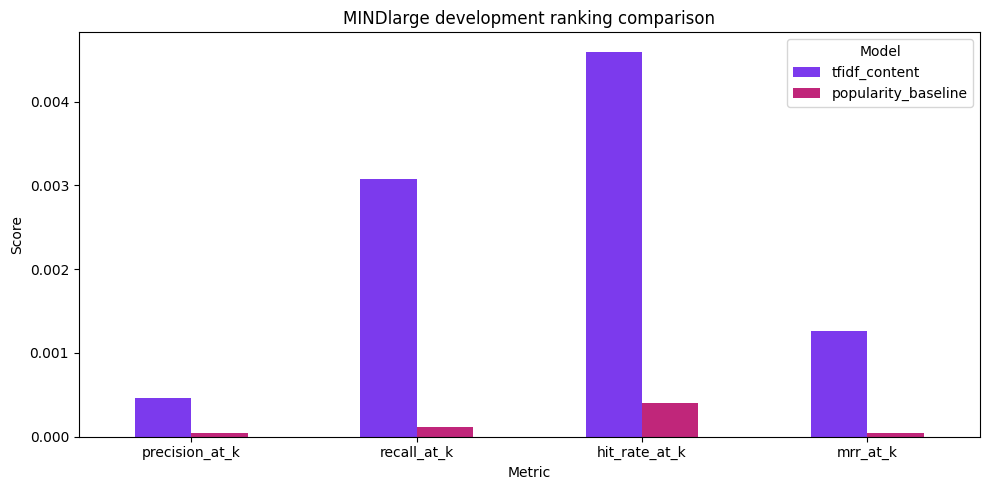

In [31]:
import matplotlib.pyplot as plt

metric_columns = ["precision_at_k", "recall_at_k", "hit_rate_at_k", "mrr_at_k"]
comparison[metric_columns].T.plot(kind="bar", figsize=(10, 5), color=["#7C3AED", "#C0267A"])
plt.title("MINDlarge development ranking comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## 9. Serialize the inference artifact

The artifact contains everything required by the API: the fitted vectorizer, sparse item matrix, news metadata, ID mapping, and training metadata. The raw dataset is not needed for request-time inference.

In [32]:
import hashlib
import pickle

news_fingerprint = hashlib.sha256(
    pd.util.hash_pandas_object(news[["news_id", "title"]], index=False).values.tobytes()
).hexdigest()

artifact = {
    "artifact_version": "1.0.0",
    "model_type": "tfidf_content_recommender",
    "vectorizer": vectorizer,
    "item_matrix": item_matrix,
    "news": news[["news_id", "category", "subcategory", "title"]].copy(),
    "news_id_to_index": news_id_to_index,
    "training_metadata": {
        "dataset": "MINDlarge_train",
        "validation_dataset": "MINDlarge_dev",
        "news_count": int(len(news)),
        "vocabulary_size": int(len(vectorizer.vocabulary_)),
        "precision_at_10": float(model_metrics["precision_at_k"]),
        "recall_at_10": float(model_metrics["recall_at_k"]),
        "hit_rate_at_10": float(model_metrics["hit_rate_at_k"]),
        "mrr_at_10": float(model_metrics["mrr_at_k"]),
        "popularity_baseline": {key: float(value) for key, value in baseline_metrics.items()},
        "evaluation_rows": int(model_metrics["evaluated_rows"]),
        "random_state": RANDOM_STATE,
        "news_fingerprint": news_fingerprint,
    },
}

with MODEL_PATH.open("wb") as handle:
    pickle.dump(artifact, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved artifact: {MODEL_PATH}")
print(f"Artifact size: {MODEL_PATH.stat().st_size / 1024 / 1024:.2f} MB")

Saved artifact: /home/student/Downloads/mindNews-recommender/mind-news-recommender/data/artifacts/model.pkl
Artifact size: 20.99 MB


## 10. Reload and verify the artifact

Reloading the saved file in the notebook mirrors the FastAPI startup path. This catches incomplete serialization before deployment.

In [33]:
with MODEL_PATH.open("rb") as handle:
    loaded_artifact = pickle.load(handle)

required_keys = {"vectorizer", "item_matrix", "news", "news_id_to_index", "training_metadata"}
assert required_keys.issubset(loaded_artifact)
assert loaded_artifact["item_matrix"].shape[0] == len(loaded_artifact["news"])
assert loaded_artifact["training_metadata"]["dataset"] == "MINDlarge_train"

print("Artifact reload passed.")
print("Ready for FastAPI inference:", MODEL_PATH)

Artifact reload passed.
Ready for FastAPI inference: /home/student/Downloads/mindNews-recommender/mind-news-recommender/data/artifacts/model.pkl


## Summary

This notebook produced a reproducible, explainable MINDlarge recommendation baseline.

### What was implemented

- Validated MINDlarge train and development files.
- Cleaned and vectorized news titles with TF-IDF unigrams and bigrams.
- Built a user profile from clicked article vectors.
- Ranked unseen articles with sparse cosine similarity.
- Added a popularity baseline for comparison.
- Evaluated Precision@10, Recall@10, Hit Rate@10, and MRR@10.
- Inspected inferred interest terms and recommendation inputs.
- Serialized and reloaded a production inference artifact.

### How to run the application

After this notebook completes successfully:

```bash
python -m uvicorn main:app --host 127.0.0.1 --port 8000
python -m streamlit run streamlit_app.py
```

Then open `http://localhost:8501` and submit valid MIND news IDs. Streamlit will show the user's inferred terms, article titles, recommendation scores, and reasons.

### Next experiments

The next useful comparisons are title plus abstract features, category features, a hybrid TF-IDF model, and the MIND entity embeddings. Each experiment should be compared with the same held-out evaluation protocol.